In [1]:
import pandas as pd
from detecto import core, utils, visualize
import matplotlib.pyplot as plt
from detecto.visualize import show_labeled_image, plot_prediction_grid
import os

In [2]:
# load data_final to pickle
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/'

data_NZ2023_a_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_a_final2.pkl')
data_NZ2023_b_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_b_final2.pkl')
data_NZ2023_c_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_c_final2.pkl')
data_NZ2023_d_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_d_final2.pkl')
data_NZ2024_a_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_a_final2.pkl')
data_NZ2024_b_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_b_final2.pkl')
data_NZ2024_c_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_c_final2.pkl')
data_NZ2024_d_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_d_final2.pkl')
data_UK2024_a_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_a_final2.pkl')
data_UK2024_b_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_b_final2.pkl')
data_UK2024_c_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_c_final2.pkl')
data_UK2024_d_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_d_final2.pkl')

### Find average tensor size


In [161]:
print(data_NZ2023_b_final2) 



                                         Image_folder_B    image_filename_B  \
0     20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_003.png   
6     20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_007.png   
12    20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_011.png   
18    20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_015.png   
24    20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_019.png   
...                                                 ...                 ...   
1664  20230404 Braeburn TG/2023-04-04_018/2023-04-04...  2023-04-04_018.png   
1670  20230404 Braeburn TG/2023-04-04_022/2023-04-04...  2023-04-04_022.png   
1676  20230404 Braeburn TG/2023-04-04_026/2023-04-04...  2023-04-04_026.png   
1682  20230404 Braeburn TG/2023-04-04_030/2023-04-04...  2023-04-04_030.png   
1688  20230404 Braeburn TG/2023-04-04_034/2023-04-04...  2023-04-04_034.png   

                 ID  Number  Firmness1  Firmness2  

tensor([ 27.8681, 112.0145, 156.2105, 226.3902])


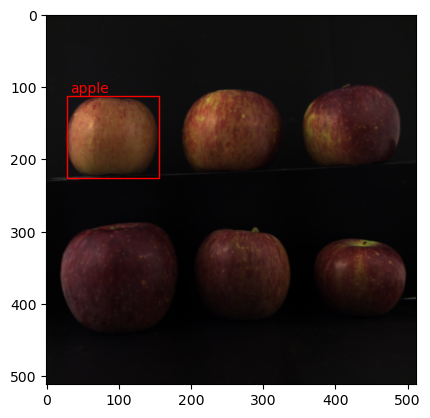

In [3]:
folder_path = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/"
image_path = (folder_path + data_NZ2023_b_final2['Image_folder_B'][0])

# print(image_path) # /media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_003/2023-03-28_003.png

image = utils.read_image(image_path)

tensors = data_NZ2023_b_final2['sorted_tensor'][0]

tensor_coordinates = tensors[0]

print(tensor_coordinates)   # tensor([ 27.8681, 112.0145, 156.2105, 226.3902])
                            # tensors = x_min, y_min, x_max, y_max

show_labeled_image(image, tensor_coordinates, ['apple'])




In [4]:
file_list = [   data_NZ2023_a_final2,
                data_NZ2023_b_final2,
                data_NZ2023_c_final2,
                data_NZ2023_d_final2,
                data_NZ2024_a_final2,
                data_NZ2024_b_final2,
                data_NZ2024_c_final2,
                data_NZ2024_d_final2,
                data_UK2024_a_final2,
                data_UK2024_b_final2,
                data_UK2024_c_final2,
                data_UK2024_d_final2]

file_list_str = [
    "data_NZ2023_a_final2",
    "data_NZ2023_b_final2",
    "data_NZ2023_c_final2",
    "data_NZ2023_d_final2",
    "data_NZ2024_a_final2",
    "data_NZ2024_b_final2",
    "data_NZ2024_c_final2",
    "data_NZ2024_d_final2",
    "data_UK2024_a_final2",
    "data_UK2024_b_final2",
    "data_UK2024_c_final2",
    "data_UK2024_d_final2"
]


In [5]:
# Change Cox to Cos's Orange Pippin in all file_lists

for file in file_list:
    file['Cultivar'] = file['Cultivar'].replace('Cox', "Cox's Orange Pippin")   
    

In [165]:
# Calculate the average height and width of tensors (get the average size of the bounding boxes)
  
total_width = 0
total_height = 0
total_apples = 0
    
for file in file_list:

    bounding_boxes = file['sorted_tensor']

    # flatten lists of tensors
    flattened_bounding_boxes = [box for sublist in bounding_boxes for box in sublist]

    # print(flattened_bounding_boxes)
 
    # iternate through list of bounding boxes 
    # # tensors = x_min, y_min, x_max, y_max
    for box in flattened_bounding_boxes:
        width = box[2] - box[0]
        height = box[3] - box[1]
        total_width += width
        total_height += height

    total_apples += len(flattened_bounding_boxes)

avg_width = total_width / total_apples
avg_height = total_height / total_apples

print(avg_width, avg_height) 

tensor(129.5094) tensor(123.7052)


In [166]:
# Calculate the average height and width of tensors (get the average size of the bounding boxes) but split by cultivar first

results = []
for i in enumerate(file_list):
   
    file = file_list[i[0]]
    file_name = file_list_str[i[0]]
    file_grouped = file.groupby('Cultivar')

    total_width = 0
    total_height = 0
    total_apples = 0

    keys = file_grouped.groups.keys()

    for cultivar in keys:
        group = file_grouped.get_group(cultivar)
        bounding_boxes = group['sorted_tensor']

        # flatten lists of tensors
        flattened_bounding_boxes = [box for sublist in bounding_boxes for box in sublist]

        # print(flattened_bounding_boxes)
    
        # iternate through list of bounding boxes 
        # # tensors = x_min, y_min, x_max, y_max
        for box in flattened_bounding_boxes:
            width = box[2] - box[0]
            height = box[3] - box[1]
            total_width += width
            total_height += height

        total_apples += len(flattened_bounding_boxes)

        avg_width = total_width / total_apples
        avg_height = total_height / total_apples

        results.append([file_name, cultivar, avg_width, avg_height])
    
results_df = pd.DataFrame(results, columns = ['File', 'Cultivar', 'Average_width', 'Average_height'])

print(results_df)



                    File             Cultivar     Average_width  \
0   data_NZ2023_a_final2             Braeburn  tensor(141.2299)   
1   data_NZ2023_a_final2  Cox's Orange Pippin  tensor(122.3758)   
2   data_NZ2023_a_final2                 Fuji  tensor(126.3361)   
3   data_NZ2023_a_final2                 Gala  tensor(129.2311)   
4   data_NZ2023_a_final2     Golden Delicious  tensor(130.9600)   
5   data_NZ2023_b_final2             Braeburn  tensor(136.7246)   
6   data_NZ2023_b_final2  Cox's Orange Pippin  tensor(121.6515)   
7   data_NZ2023_b_final2                 Fuji  tensor(124.9784)   
8   data_NZ2023_b_final2                 Gala  tensor(128.4192)   
9   data_NZ2023_b_final2     Golden Delicious  tensor(130.2042)   
10  data_NZ2023_c_final2             Braeburn  tensor(140.3479)   
11  data_NZ2023_c_final2  Cox's Orange Pippin  tensor(122.3962)   
12  data_NZ2023_c_final2                 Fuji  tensor(125.9491)   
13  data_NZ2023_c_final2                 Gala  tensor(128.9975

In [167]:
Avg_tensor_size = results_df

Avg_tensor_size.to_pickle(f'{pickle_path}Avg_tensor_size.pkl')

In [168]:
# Calculate mean size by cultivar

grouped_Avg_tensor_size = Avg_tensor_size.groupby('Cultivar')

Overall_results = []

for group in grouped_Avg_tensor_size.groups:
    height_mean = grouped_Avg_tensor_size.get_group(group)['Average_height'].mean()
    width_mean = grouped_Avg_tensor_size.get_group(group)['Average_width'].mean()
    Overall_results.append([group, height_mean, width_mean])

Overall_results_df = pd.DataFrame(Overall_results, columns = ['Cultivar', 'Average_height', 'Average_width'])





In [6]:
# Calculate the minimum size of tensors (get the minimum size of the bounding boxes)

min_width = 500
min_height = 500
min_apples = 500
    
for file in file_list:

    bounding_boxes = file['sorted_tensor']

    # flatten lists of tensors
    flattened_bounding_boxes = [box for sublist in bounding_boxes for box in sublist]

    # print(flattened_bounding_boxes)
 
    # iternate through list of bounding boxes 
    # # tensors = x_min, y_min, x_max, y_max
    for box in flattened_bounding_boxes:
        width = box[2] - box[0]
        height = box[3] - box[1]

        if height < min_height:
            min_height = height

        if width < min_width:
            min_width = width

print(min_width, min_height) 

tensor(79.9488) tensor(74.8289)


In [169]:
print(Overall_results_df)

Overall_results_df.to_pickle(f'{pickle_path}Result_tables/Overall_avg_cultivar_size_df.pkl')

              Cultivar  Average_height  Average_width
0             Braeburn      129.780986     135.518483
1  Cox's Orange Pippin      117.677185     121.750778
2                 Fuji      123.260651     131.336802
3                 Gala      123.905019     131.619334
4     Golden Delicious      124.952688     132.355581
5                 Jazz      120.418594     119.478455


In [170]:
# Cahnge column names
Overall_results_df.columns = ['Cultivar', 'Average height', 'Average width']

# Change to 2 s.f 

# Overall_results_df['Average height'] = Overall_results_df['Average height'].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)
# Overall_results_df['Average width'] = Overall_results_df['Average width'].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)


# Change to whole number

Overall_results_df['Average height'] = Overall_results_df['Average height'].round().astype(int)
Overall_results_df['Average width'] = Overall_results_df['Average width'].round().astype(int)


print(Overall_results_df)

Overall_results_df.to_latex(f'{pickle_path}Result_tables/Overall_avg_cultivar_size_df.tex', index = False)

              Cultivar  Average height  Average width
0             Braeburn             130            136
1  Cox's Orange Pippin             118            122
2                 Fuji             123            131
3                 Gala             124            132
4     Golden Delicious             125            132
5                 Jazz             120            119


## Assessing why Fuji 976 keeps getting predicted as outliers


In [63]:
import numpy as np
import pandas as pd
from detecto import utils
from detecto.visualize import show_labeled_image

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [50]:
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/'

# load data
data_NZ2024_a_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_a_final2.pkl')


In [ ]:
#Find the file containing the missing image

#print the first match of the ID

print(data_NZ2024_a_final2[data_NZ2024_a_final2['ID'] == 'Fuji_976'])
print(data_NZ2024_a_final2[data_NZ2024_a_final2['ID'] == 'Fuji_976']['sorted_tensor'])

                                      Image_folder_A    image_filename_A  \
769  20240328 Fuji/2024-03-28_017/2024-03-28_017.png  2024-03-28_017.png   

           ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
769  Fuji_976      25       8.81       9.13  15.38      88      3.0  1.749675   

     Avg_firmness Cultivar                                      sorted_tensor  \
769          8.97     Fuji  [[tensor(7.7903), tensor(148.1798), tensor(151...   

     number_of_apples  Count  
769                 6      6  
769    [[tensor(7.7903), tensor(148.1798), tensor(151...
Name: sorted_tensor, dtype: object


20240328 Fuji/2024-03-28_017/2024-03-28_017.png
/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/20240328 Fuji/2024-03-28_017/2024-03-28_017.png


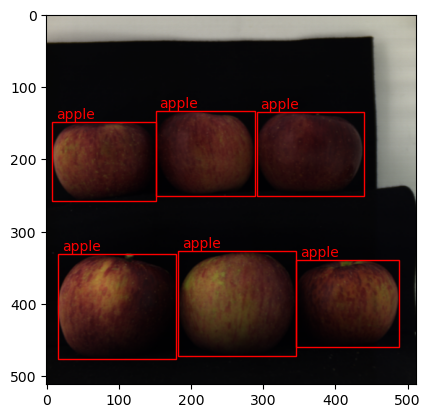

In [ ]:
# Load the missing image

folder_path = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/"
file_name = data_NZ2024_a_final2[data_NZ2024_a_final2['ID'] == 'Fuji_976']['Image_folder_A'].iloc[0]

print(file_name)

image_path = (folder_path + file_name)

print(image_path) # 

image = utils.read_image(image_path)

# tensors = data_NZ2024_a_final2['sorted_tensor'][0]
# tensor_coordinates = tensors[0]

tensors = data_NZ2024_a_final2[data_NZ2024_a_final2['ID'] == 'Fuji_976']['sorted_tensor'].iloc[0]

tensor_coordinates = tensors

# print(tensor_coordinates)   # tensor([ 27.8681, 112.0145, 156.2105, 226.3902])
                            # tensors = x_min, y_min, x_max, y_max

show_labeled_image(image, tensor_coordinates, ['apple','apple','apple','apple','apple','apple'])





In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())
print(tf.test.gpu_device_name())


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
True
/device:GPU:0


2025-03-10 17:19:36.777851: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 79086 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2025-03-10 17:19:36.780130: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:1 with 79086 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


### How many apples per cultivar?



In [6]:
data_NZ2023_a = data_NZ2023_a_final2
data_NZ2023_b = data_NZ2023_b_final2
data_NZ2023_c = data_NZ2023_c_final2
data_NZ2023_d = data_NZ2023_d_final2
data_NZ2024_a = data_NZ2024_a_final2
data_NZ2024_b = data_NZ2024_b_final2
data_NZ2024_c = data_NZ2024_c_final2
data_NZ2024_d = data_NZ2024_d_final2
data_UK2024_a = data_UK2024_a_final2
data_UK2024_b = data_UK2024_b_final2
data_UK2024_c = data_UK2024_c_final2
data_UK2024_d = data_UK2024_d_final2

data_NZ2023_a['Year'] = '2023'
data_NZ2023_b['Year'] = '2023'
data_NZ2023_c['Year'] = '2023'
data_NZ2023_d['Year'] = '2023'
data_NZ2024_a['Year'] = '2024'
data_NZ2024_b['Year'] = '2024'
data_NZ2024_c['Year'] = '2024'
data_NZ2024_d['Year'] = '2024'
data_UK2024_a['Year'] = '2024'
data_UK2024_b['Year'] = '2024'
data_UK2024_c['Year'] = '2024'
data_UK2024_d['Year'] = '2024'



all_cultivars = pd.concat([data_NZ2023_a,
                            data_NZ2023_b,
                            data_NZ2023_c,
                            data_NZ2023_d,
                            data_NZ2024_a,
                            data_NZ2024_b,
                            data_NZ2024_c,
                            data_NZ2024_d,
                            data_UK2024_a,
                            data_UK2024_b,
                            data_UK2024_c,
                            data_UK2024_d])

In [10]:
print(all_cultivars.head())

                                       Image_folder_A    image_filename_A  \
0   20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
6   20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_006.png   
12  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_010.png   
18  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_014.png   
24  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_018.png   

         ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
0    Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
6    Fuji_7     7.0       6.34       6.92  12.67    33.0      9.0  4.709550   
12  Fuji_13    13.0       7.09       7.61  12.40    25.0      9.0  5.334677   
18  Fuji_19    19.0       7.80       9.14  12.26    69.0      6.0  4.145188   
24  Fuji_25    25.0       7.42       7.25  13.92    17.0     10.0  5.269397   

    Avg_firmness Cultivar                                     

In [7]:
summary_df = all_cultivars.groupby(['Cultivar']).size().reset_index(name='Counts')

print(summary_df)

              Cultivar  Counts
0             Braeburn     700
1                  Cox      43
2  Cox's Orange Pippin     180
3                 Fuji     958
4                 Gala    1082
5     Golden Delicious     488
6                 Jazz      12


In [1]:
# Test code
import numpy as np
img_size = 20
if img_size == 20 or img_size == 14:
    training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_Feb2025/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_50px/all_years/'

# X_train_brix          = np.load(f'{training_data_path}X_train_all_years_Brix_shuffled.npy')
# Y_train_brix          = np.load(f'{training_data_path}Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix       = np.load(f'{training_data_path}X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix       = np.load(f'{training_data_path}Y_validate_all_years_Brix_shuffled.npy')
# Brix_encoder_shuffled  = np.load(f'{training_data_path}X_train_all_years_Brix_encoder_shuffled.npy')
# validate_encoder        = np.load(f'{training_data_path}X_validate_all_years_Brix_encoder_shuffled.npy')

# Side A

X_train_brix          = np.load(f'{training_data_path}Side_A_X_train_all_years_Brix_shuffled.npy')
Y_train_brix          = np.load(f'{training_data_path}Side_A_Y_train_all_years_Brix_shuffled.npy')
X_validate_brix       = np.load(f'{training_data_path}Side_A_X_validate_all_years_Brix_shuffled.npy')
Y_validate_brix       = np.load(f'{training_data_path}Side_A_Y_validate_all_years_Brix_shuffled.npy')
Brix_encoder_shuffled  = np.load(f'{training_data_path}Side_A_X_train_all_years_Brix_encoder.npy')
validate_encoder        = np.load(f'{training_data_path}Side_A_X_validate_all_years_Brix_encoder.npy')

spectral_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/'

X_train_brix = [spectral_path + file for file in X_train_brix]
X_validate_brix = [spectral_path + file for file in X_validate_brix]


In [4]:
print(X_train_brix[0])

/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/UK2024/20px_Golden Delicious_2363_2195.npy


In [3]:
test = np.load(X_train_brix[0])

FileNotFoundError: [Errno 2] No such file or directory: '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/UK2024/20px_Golden Delicious_2363_2195.npy'

In [ ]:
import pandas as pd

path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Bayesian_optimisation_files/"

brix_dict = pd.read_pickle(f'{path}bayesian_optimization_results_brix_ViT.pkl')
print(brix_dict.loc[brix_dict['val_loss'].idxmin()])

firmness_dict = pd.read_pickle(f'{path}bayesian_optimization_results_firmness_ViT.pkl')
print(firmness_dict.loc[firmness_dict['val_loss'].idxmin()])

starch_dict = pd.read_pickle(f'{path}bayesian_optimization_results_starch_ViT.pkl')
print(starch_dict.loc[starch_dict['val_loss'].idxmin()])




patch_size                   8
projection_dim             256
transformer_layers           5
num_heads                    3
mlp_head_units         256-128
dropout_rate               0.1
val_loss              0.725627
Name: 25, dtype: object


# Combine predicted vs actual graphs into 1 

In [1]:
import pandas as pd
# Load graphs
brix_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_13_ViT_results/brix_vit_prediction_results.csv')
firmness_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_13_ViT_results/firmness_vit_prediction_results.csv')
starch_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_13_ViT_results/starch_vit_prediction_results.csv')


In [11]:
# plot the graphs
import matplotlib.pyplot as plt
# 自定义计算评估指标的函数 # Custom function to calculate evaluation metrics
def calculate_metrics(y_true, y_pred):
    # 计算MSE
    mse = np.mean((y_true - y_pred) ** 2)
    # 计算RMSE
    rmse = np.sqrt(mse)
    # 计算MAE
    mae = np.mean(np.abs(y_true - y_pred))
    # 计算R²
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    return mse, rmse, mae, r2


# 对测试集进行预测并可视化 # Make predictions on the test set and visualize

def predict_and_visualize(predictions, test_targets, ax, label):
    mse, rmse, mae, r2 = calculate_metrics(test_targets, predictions)

    ax.scatter(test_targets, predictions, alpha=0.5)
    ax.plot([min(test_targets), max(test_targets)], [min(test_targets), max(test_targets)], 'r--')
    ax.set_title(f'')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
        fontsize=14, fontweight='bold', va='top', ha='left')

    ax.grid(True)

    # Add evaluation metrics text
    ax.text(0.05, 0.95, f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))



  
    


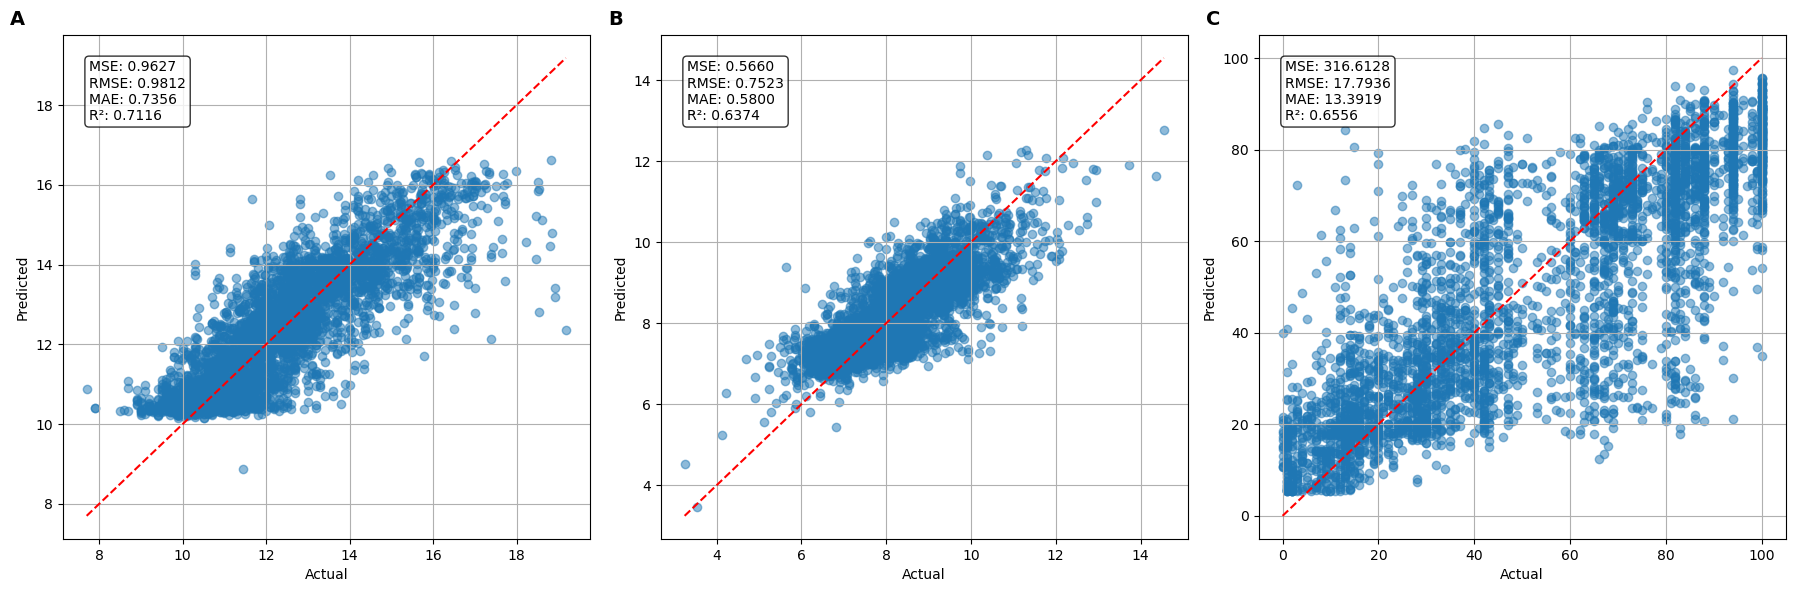

In [ ]:
# For run 13, optimised bays # Wrong run - should be 20
import numpy as np
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Generate each subplot with labels A, B, and C
predict_and_visualize(brix_data['Predicted'], brix_data['Actual'], axes[0], 'A')
predict_and_visualize(firmness_data['Predicted'], firmness_data['Actual'], axes[1], 'B')
predict_and_visualize(starch_data['Predicted'], starch_data['Actual'], axes[2], 'C')

plt.tight_layout()
plt.show()

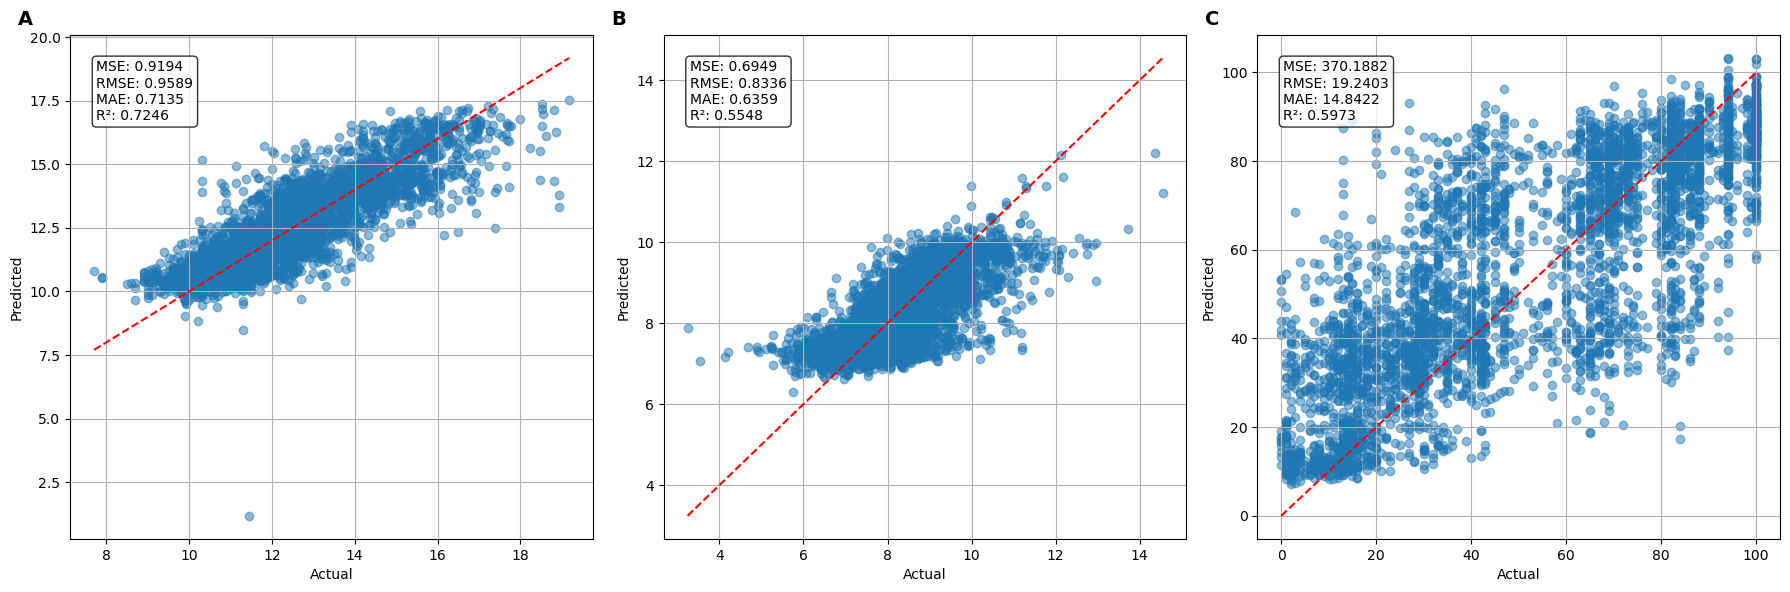

In [13]:
# For run 26, single side A
import pandas as pd
# Load graphs
brix_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_26_ViT_results/brix_vit_prediction_results.csv')
firmness_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_26_ViT_results/firmness_vit_prediction_results.csv')
starch_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_26_ViT_results/starch_vit_prediction_results.csv')



import numpy as np
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Generate each subplot with labels A, B, and C
predict_and_visualize(brix_data['Predicted'], brix_data['Actual'], axes[0], 'A')
predict_and_visualize(firmness_data['Predicted'], firmness_data['Actual'], axes[1], 'B')
predict_and_visualize(starch_data['Predicted'], starch_data['Actual'], axes[2], 'C')

plt.tight_layout()
plt.show()

In [ ]:
# For run 22, 50% wavelengths removed
import pandas as pd
# Load graphs
brix_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_22_ViT_results/brix_vit_prediction_results.csv')
firmness_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_21_ViT_results/firmness_vit_prediction_results.csv')
starch_data = pd.read_csv('/media/2tbdisk3/data/Haidee/Results/Predictions/run_22_ViT_results/starch_vit_prediction_results.csv')



import numpy as np
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Generate each subplot with labels A, B, and C
predict_and_visualize(brix_data['Predicted'], brix_data['Actual'], axes[0], 'A')
predict_and_visualize(firmness_data['Predicted'], firmness_data['Actual'], axes[1], 'B')
predict_and_visualize(starch_data['Predicted'], starch_data['Actual'], axes[2], 'C')

plt.tight_layout()
plt.show()